# Analitica de Marketing en Showz (Analisis de Cohortes)

### Descripción del proyecto

Lo has hecho de maravilla en el curso de TripleTen y te han ofrecido hacer prácticas en el departamento de analítica de Showz, una empresa de venta de entradas de eventos. Tu primera tarea es ayudar a optimizar los gastos de marketing. 

Cuentas con:

* registros del servidor con datos sobre las visitas a Showz desde enero de 2017 hasta diciembre de 2018;
* un archivo con los pedidos en este periodo;
* estadísticas de gastos de marketing.

Lo que vas a investigar: 

* cómo los clientes usan el servicio;
* cuándo empiezan a comprar;
* cuánto dinero aporta cada cliente a la compañía;
* cuándo los ingresos cubren el costo de adquisición de los clientes.

## Paso 1. Acceder a los datos y prepáralos para el análisis

Comenzamos preparando los datos para el analisis. Tenemos 3 datasets que vamos a almacenar en variables. Vamos a optimizar los datos y asegurarnos de que cada columna contenga el tipo de datos correcto.

Vamos a almacenar los datos de visitas, pedidos y gastos en variables.  Luego vamos a optimizar los datos para el análisis y asegurarnos de que cada columna contenga el tipo de datos correcto. 

Rutas de archivos: 

- `/datasets/visits_log_us.csv`
- `/datasets/orders_log_us.csv`
- `/datasets/costs_us.csv`

In [1]:
# Importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats as st

In [2]:
# Leer y almancenar los datasets en variables
visits = pd.read_csv('datasets/visits_log_us.csv')
orders = pd.read_csv('datasets/orders_log_us.csv')
costs = pd.read_csv('datasets/costs_us.csv')

In [3]:
# Visualizar y observar los datasets
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [4]:
# Visualizar y observar los datasets
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [5]:
# Visualizar y observar los datasets
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [6]:
# Imprimir una muestra de cada dataset
visits.head(10)

,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168
5,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387
6,desktop,2018-01-30 12:09:00,1,2018-01-30 11:13:00,6661610529277171451
7,touch,2017-11-05 15:15:00,3,2017-11-05 15:14:00,11423865690854540312
8,desktop,2017-07-19 10:44:00,3,2017-07-19 10:41:00,2987360259350925644
9,desktop,2017-11-08 13:43:00,5,2017-11-08 13:42:00,1289240080042562063


In [7]:
# Imprimir una muestra de cada dataset
orders.head(10)

,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450
5,2017-06-01 08:43:00,0.18,10402394430196413321
6,2017-06-01 08:54:00,1.83,12464626743129688638
7,2017-06-01 09:22:00,1.22,3644482766749211722
8,2017-06-01 09:22:00,3.30,17542070709969841479
9,2017-06-01 09:23:00,0.37,1074355127080856382


In [8]:
# Imprimir una muestra de cada dataset
costs.head(10)

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
5,1,2017-06-06,40.39
6,1,2017-06-07,40.59
7,1,2017-06-08,56.63
8,1,2017-06-09,40.16
9,1,2017-06-10,43.24


### === Observaciones iniciales de los datos ===

Como se menciona en la descripcion del proyecto, tenemos 3 sets de datos con con informacion del registro de visitas al sitio web de Showz, otro dataset con informacion de los pedidos realizados por usuarios y finalmente un dataset con informacion de los gastos de marketing por fecha. No parece haber datos ausentes en ningun dataset, pero debemos asegurarnos y revisar duplicados. Parece buena idea estandarizar nombres de columnas y corrigir tipos de datos.

### 1.1 Revisar valores ausentes y duplicados

No parace haber anomalias en los datos, pero para asegurarnos vamos a examinar su hay duplicados y valores ausentes.

In [9]:
# Revisar si existen valores ausentes en el dataset de visitas
print("Valores ausentes en el dataset de visitas: \n")
visits.isna().sum()

Valores ausentes en el dataset de visitas: 



Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64

In [10]:
# Revisar si existen duplicados en el dataset de visitas
print("Duplicados en el dataset de visitas: \n")
print(visits.duplicated().sum())

Duplicados en el dataset de visitas: 

0


In [11]:
# Revisar si existen valores ausentes en el dataset de ordenes
print("Valores ausentes en el dataset de ordenes: \n")
orders.isna().sum()

Valores ausentes en el dataset de ordenes: 



Buy Ts     0
Revenue    0
Uid        0
dtype: int64

In [12]:
# Revisar si existen duplicados en el dataset de ordenes
print("Duplicados en el dataset de ordenes: \n")
print(orders.duplicated().sum())

Duplicados en el dataset de ordenes: 

0


In [13]:
# Revisar si existen valores ausentes en el dataset de costos
print("Valores ausentes en el dataset de costos: \n")
print(costs.isna().sum())

Valores ausentes en el dataset de costos: 

source_id    0
dt           0
costs        0
dtype: int64


In [14]:
# Revisar si existen duplicados en el dataset de costos
print("Duplicados en el dataset de costos: \n")
print(costs.duplicated().sum())

Duplicados en el dataset de costos: 

0


### === Notas de revision de ausentes y duplicados ===

Los tres datasets que tenemos no tienen valores ausentes y tampoco filas duplicadas, lo cual es muy buena noticia. Seria buena idea estandarizar los nombres de las columnas a minusculas y guion bajo en vez de espacios en blanco. Ademas las columnas que contienen informacion de fechas son de tipo "object" o "string" por lo que seria recomendable transformar esas columnas a tipo "datetime".

### 1.2 Estandizar nombres de columnas y corregir tipos de datos

Vamos a estandarizar los nombres de columnas a minusculas y reemplazar espacios en blanco por guion bajo. Ademas vamos a convertir las columnas correspondientes a tipo "datetime".

In [15]:
# Estandarizar a minusculas y guion bajo en los nombres de las columnas del dataset de visitas
visits.columns = visits.columns.str.lower().str.replace(' ', '_')

In [16]:
# Estandarizar a minusculas y guion bajo en los nombres de las columnas del dataset de ordenes
orders.columns = orders.columns.str.lower().str.replace(' ', '_')

In [17]:
# Estandarizar a minusculas y guion bajo en los nombres de las columnas del dataset de costos
costs.columns = costs.columns.str.lower().str.replace(' ', '_')

In [18]:
# Cambiar las columnas correspondientes a tipo datetime
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['start_ts'] = pd.to_datetime(visits['start_ts'])

In [19]:
# Cambiar las columnas correspondientes a tipo datetime
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])

In [20]:
# Cambiar las columnas correspondientes a tipo datetime
costs['dt'] = pd.to_datetime(costs['dt'])

## Paso 2. Realizar informes y calcular métricas

Vamos a comenzar el analisis exploratorio de los datos. Comenzaremos revisando y analizando los datos de visitas, luego con el dataset de "orders" o pedidos, y finalmente con los datos de costos o los gastos en marketing.

### 2.1 Dataset Visitas

Queremos obtener informacion del comportamiento de los usuarios con respecto a las visitas.

* ¿Cuántas personas lo usan cada día, semana y mes?
* ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).
* ¿Cuál es la duración de cada sesión?
* ¿Con qué frecuencia los usuarios regresan?

Comenzaremos analizando las metricas de visitas diarias, semanales y mensuales.

### 2.1.1 ¿Cuántas personas lo usan cada día, semana y mes?

Para conocer las metricas de visitas por dia, semana y mes, tenemos que crear una columna especifica para ello, lo cual nos permitira agrupar y posteriormente contar las visitas, con lo cual sabremos cuantas personas tenemos por dia, semana y mes.

In [21]:
# Crear columnas para dia, semana y mes
visits['day'] = visits['start_ts'].dt.date
visits['week'] = visits['start_ts'].dt.strftime('%Y-%m-%W')
visits['month'] = visits['start_ts'].dt.strftime('%Y-%m')

In [22]:
# Revisar los cambios y las columnas creadas
visits.head()

,device,end_ts,source_id,start_ts,uid,day,week,month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-51,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-08,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-26,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,2018-05
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-52,2017-12


### 2.1.2 Visitas diarias, semanales y mensuales

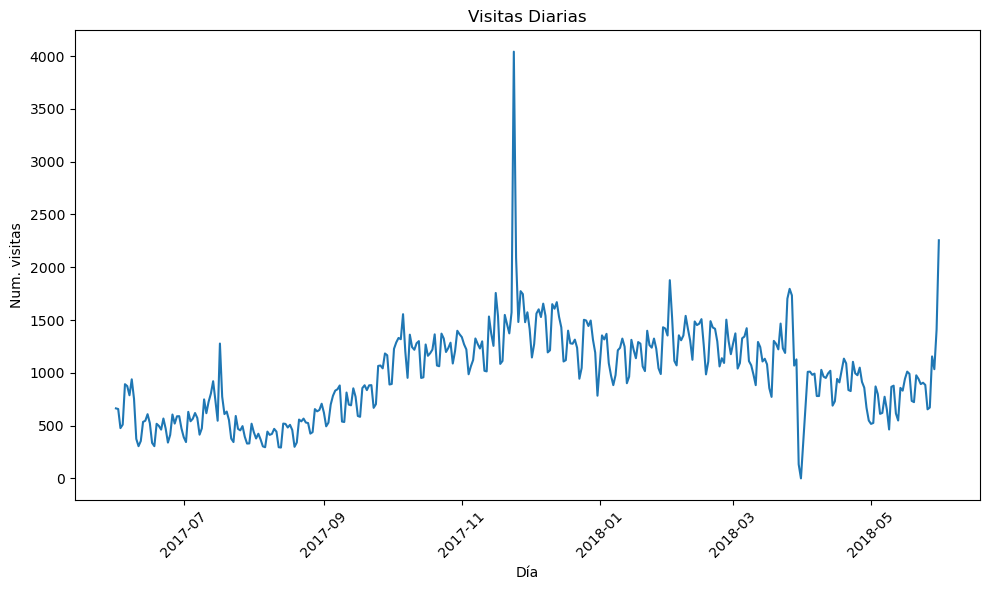

In [123]:
# Agrupar por dia y graficar las visitas diarias
groupby_day = visits.groupby('day')['uid'].count()

# Graficar las visitas diarias
groupby_day.plot(kind='line', title='Visitas Diarias', xlabel='Día', ylabel='Num. visitas', rot=45, figsize=(10,6))
plt.tight_layout()
plt.show()

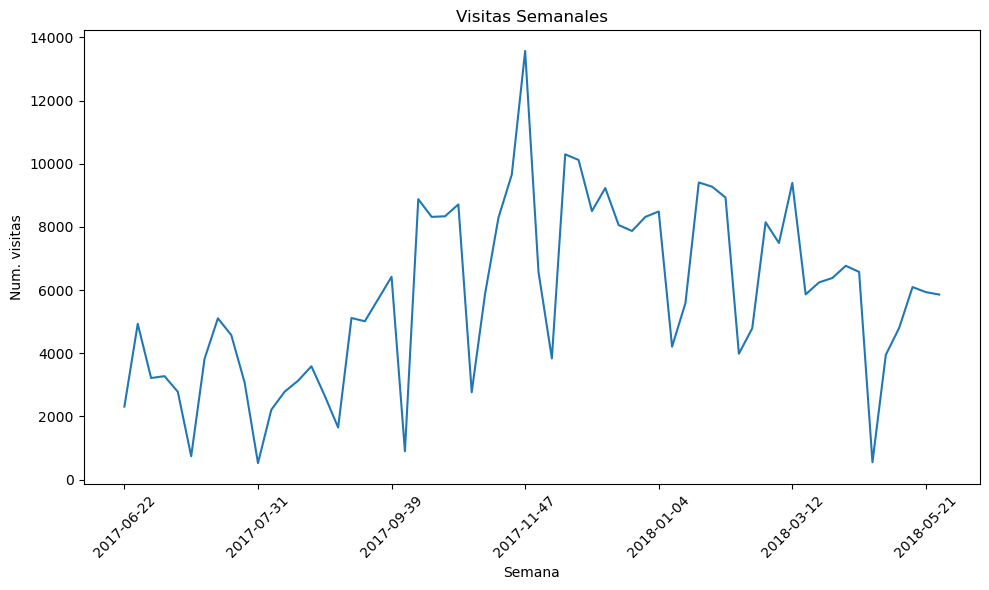

In [124]:
# Agrupar por semana y graficar las visitas semanales
groupby_week = visits.groupby('week')['uid'].count()
groupby_week.plot(kind='line', title='Visitas Semanales', xlabel='Semana', ylabel='Num. visitas', rot=45, figsize=(10, 6))
plt.tight_layout()
plt.show()

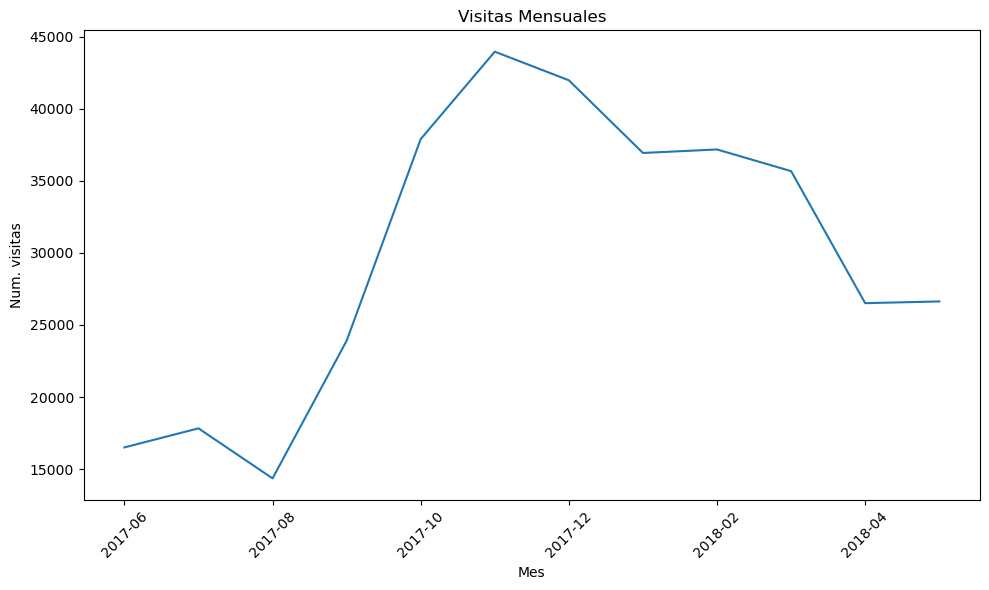

In [125]:
# Agrupar por mes y graficar las visitas mensuales
groupby_month = visits.groupby('month')['uid'].count()
groupby_month.plot(kind='line', title='Visitas Mensuales', xlabel='Mes', ylabel='Num. visitas', rot=45, figsize=(10, 6))
plt.tight_layout()
plt.show()

### === Observaciones de las visitas diarias, semanales y mensuales ===

Las graficas de visitas por dia, semana y mes muestran numeros consistentes. La visitas diarias suben y bajan constantemente pero en general fueron incrementandose hasta alcanzar un pico en el mes de noviembre 2017, para luego descender bruscamente pero manteniendose con cierta estabilidad. Las visitas semanales tambien muestran subidas y bajadas semana a semana, pero tambien registran un incremento visible hasta esa semana en nomviembre 2017 (probablemente la semana de black friday) donde alcanza un pico y luego desciende para mantenerse con subidas y bajadas constantes. Las visitas mensuales muestran un comportamiento similar pero de forma menos brusca.

### 2.1.3 ¿Cuántas sesiones hay por día? - Sesiones diarias, semanales y mensuales (DAU, WAU, MAU)

Para esta seccion vamos a calcular el DAU, WAU y MAU, es decir, las sesiones diarias de los usuarios, las sesiones semanales y mensuales.

In [26]:
# DAU: Usuarios unicos diarios activos
dau = visits.groupby('day')['uid'].nunique().reset_index(name='dau')
print(f"Promedio de usuarios diarios: {dau['dau'].mean()}")
dau

Promedio de usuarios diarios: 907.9917582417582


,day,dau
0,2017-06-01,605
1,2017-06-02,608
2,2017-06-03,445
3,2017-06-04,476
4,2017-06-05,820
...,...,...
359,2018-05-27,620
360,2018-05-28,1039
361,2018-05-29,948
362,2018-05-30,1289


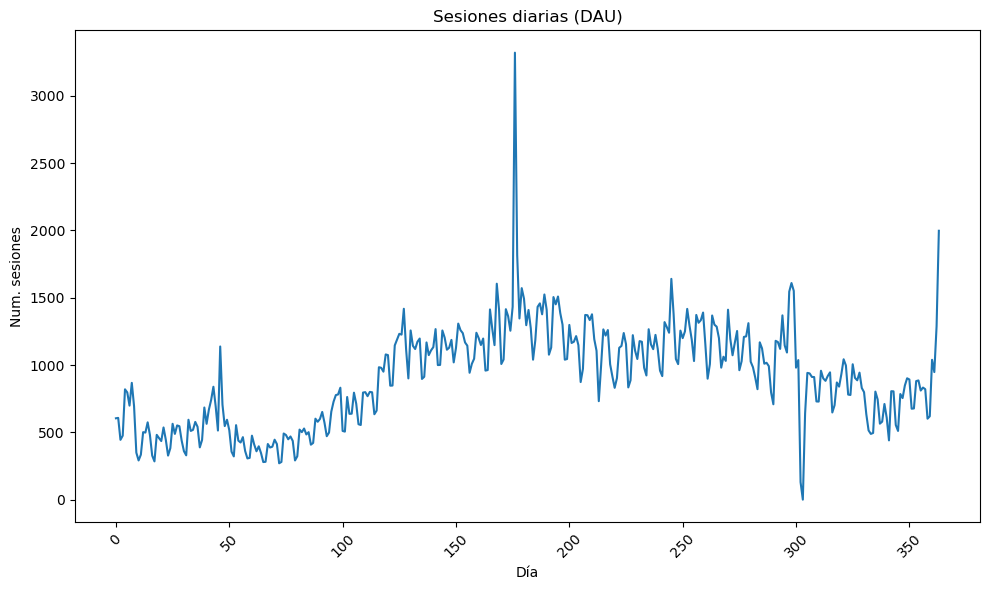

In [27]:
# Graficar DAU
dau.plot(kind='line', title='Sesiones diarias (DAU)', xlabel='Día', ylabel='Num. sesiones', rot=45, figsize=(10,6))
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [28]:
# WAU: Usuarios unicos semanales activos
wau = visits.groupby('week')['uid'].nunique().reset_index(name='wau')
print(f"Promedio de usuarios semanales: {wau['wau'].mean()}")
wau

Promedio de usuarios semanales: 4911.129032258064


,week,wau
0,2017-06-22,2021
1,2017-06-23,4129
2,2017-06-24,2812
3,2017-06-25,2878
4,2017-06-26,2435
...,...,...
57,2018-05-18,3462
58,2018-05-19,4128
59,2018-05-20,5070
60,2018-05-21,4995


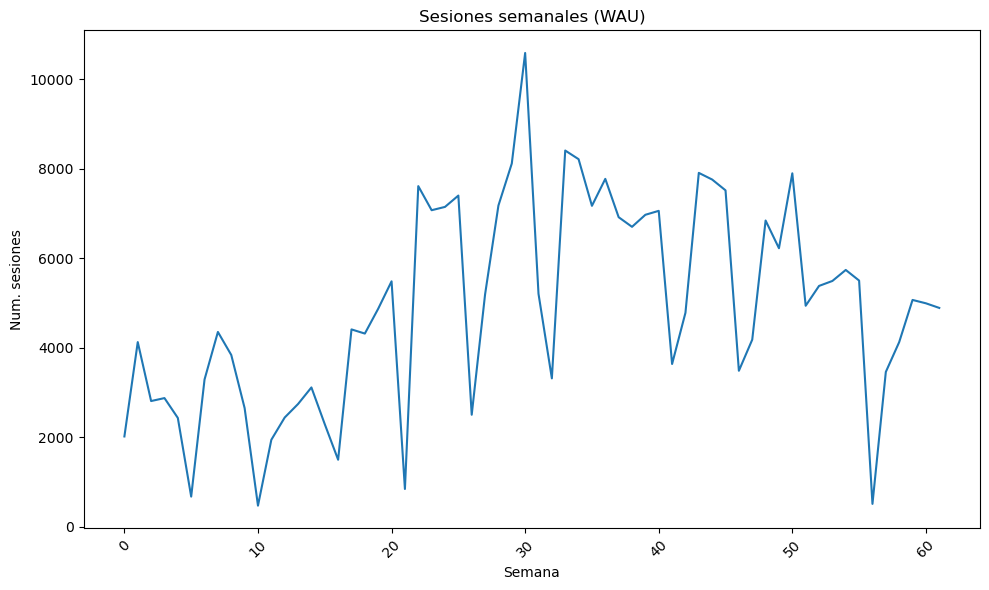

In [29]:
# Graficar WAU
wau.plot(kind='line', title='Sesiones semanales (WAU)', xlabel='Semana', ylabel='Num. sesiones', rot=45, figsize=(10,6))
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

In [30]:
# MAU: Usuarios unicos mensuales activos
mau = visits.groupby('month')['uid'].nunique().reset_index(name='mau')
print(f"Promedio de usuarios mensuales: {mau['mau'].mean()}")
mau

Promedio de usuarios mensuales: 23228.416666666668


,month,mau
0,2017-06,13259
1,2017-07,14183
2,2017-08,11631
3,2017-09,18975
4,2017-10,29692
5,2017-11,32797
6,2017-12,31557
7,2018-01,28716
8,2018-02,28749
9,2018-03,27473


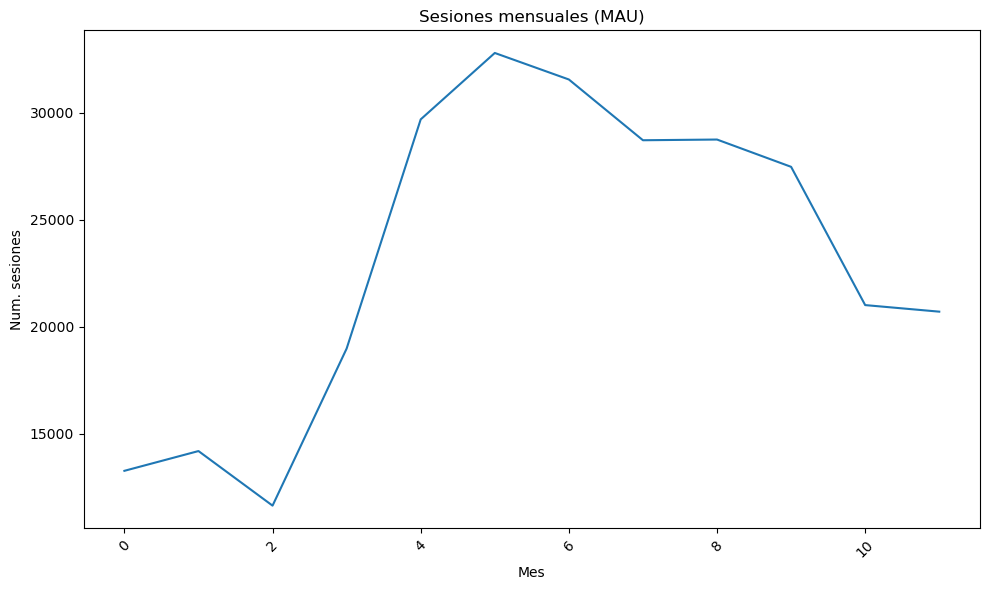

In [31]:
# Graficar MAU
mau.plot(kind='line', title='Sesiones mensuales (MAU)', xlabel='Mes', ylabel='Num. sesiones', rot=45, figsize=(10,6))
plt.legend().set_visible(False)
plt.tight_layout()
plt.show()

### === Observaciones de DAU, WAU y MAU ===

El promedio de usuarios diarios es de DAU = 907.9, el promedio de usuarios semanales es de WAU = 4911.1 y el promedio de usuarios mensuales es de MAU = 23228.4. Es de notar que las graficas de cada una tienen una forma y comportamiento similar a las graficas para las visitas diarias, semanales y mensuales respectivamente.

### 2.1.4 ¿Cuál es la duración de cada sesión?

Para obtener la duracion de cada sesion simplemente calculamos el final de cada sesion menos el incio para cada fila. Luego podemos calcular el promedio sumando la duracion de las sesiones y dividir entre el numero de sesiones totales o bien usar el metodo mean() de pandas.

Podemos crear una nueva columna que indique la duracion de cada sesion en segundos.

In [32]:
# Creamos una columna para la duracion de cada sesion en segundos
visits['session_duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.seconds
visits.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,session_duration_sec
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-51,2017-12,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-08,2018-02,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-26,2017-07,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,2018-05,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-52,2017-12,0


In [33]:
# Calculamos la duracion promedio por sesion
print(f"Duracion promedio de cada sesion: {visits['session_duration_sec'].mean()} segundos")

Duracion promedio de cada sesion: 643.506488592098 segundos


In [34]:
# Utilizamos el metodo describe para tener mas detalles 
visits['session_duration_sec'].describe()

count    359400.000000
mean        643.506489
std        1016.334786
min           0.000000
25%         120.000000
50%         300.000000
75%         840.000000
max       84480.000000
Name: session_duration_sec, dtype: float64

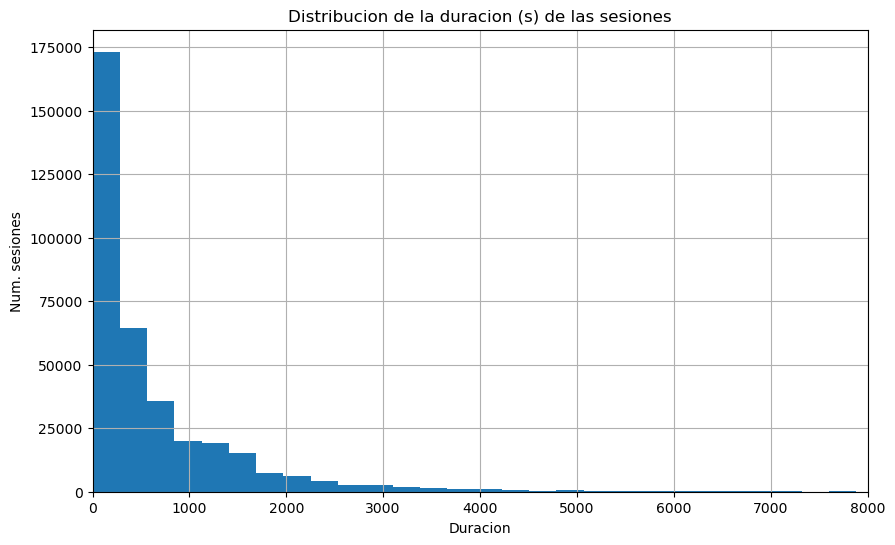

In [129]:
# Graficar el comportamiento de las sesiones con un histograma
plt.figure(figsize=(10, 6))
visits['session_duration_sec'].hist(bins=300).set(title='Distribucion de la duracion (s) de las sesiones', 
                                                  xlabel='Duracion', ylabel='Num. sesiones')
plt.xlim(0, 8000)
plt.show()

### === Observaciones de la duracion de cada sesion ===

La duracion promedio de cada sesion es de 643.5 segundos, o 10.7 minutos. La gran mayoria de las sesiones se mantienen abajo de los 1000 segundos. Un porcion mas pequeña tuvo sesiones de entre 1000 y 2000 segundos. Y un porcentaje muy bajo de sesiones superaron los 2000 segundos de duracion. Gracias al metodo describe() pudimos notar que la sesion mas larga duro 84480 segundos. Tenemos algunos pocos adictos al sitio de Showz.

### 2.1.5 ¿Con qué frecuencia los usuarios regresan? - Analisis de Cohortes

Para esta seccion queremos saber cuantos usuarios tienen mas de una visita, cuantos regresan, o en otras palabras cuanta retencion tiene el sitio web. Para ello, vamos a realizar una analisis de cohortes. Vamos a segmentar a las cohortes por la fecha de su primera visita y por meses. Estos nos servirara para analizar la tasa de retencion.

Podemos agrupar por UID y luego extraer la primera visita de cada usuario. A partir de ahi calculamos el tiempo que pasa desde la primera visita de cada usuario.

In [36]:
# Vista previa del dataframe visitas
visits.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,session_duration_sec
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-51,2017-12,1080
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-08,2018-02,1680
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-26,2017-07,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,2018-05,1440
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-52,2017-12,0


In [37]:
# Extraemos la primeras visitas por usuario
first_visits = visits.groupby('uid')['start_ts'].min().reset_index()
first_visits.columns = ['uid', 'first_visit_ts']
first_visits

,uid,first_visit_ts
0,11863502262781,2018-03-01 17:27:00
1,49537067089222,2018-02-06 15:55:00
2,297729379853735,2017-06-07 18:47:00
3,313578113262317,2017-09-18 22:49:00
4,325320750514679,2017-09-30 14:29:00
...,...,...
228164,18446403737806311543,2017-11-30 03:36:00
228165,18446424184725333426,2017-12-06 20:32:00
228166,18446556406699109058,2018-01-01 16:29:00
228167,18446621818809592527,2017-12-27 13:27:00


In [38]:
# Agregamos columnas con la informacion del dia de la primera visita, la semana y el mes en que se realizo
first_visits['first_visit_day'] = first_visits['first_visit_ts'].dt.date
first_visits['first_visit_week'] = first_visits['first_visit_ts'].dt.strftime('%Y-%m-%W')
first_visits['first_visit_month'] = first_visits['first_visit_ts'].dt.strftime('%Y-%m')

In [39]:
# Creamos un nuevo dataset para la union de 'visits' con 'first_visits'
visits_full = visits.merge(first_visits, how='inner', on='uid')

# Imprimimos el resultado
visits_full.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,session_duration_sec,first_visit_ts,first_visit_day,first_visit_week,first_visit_month
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-51,2017-12,1080,2017-12-20 17:20:00,2017-12-20,2017-12-51,2017-12
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-08,2018-02,1680,2018-02-19 16:53:00,2018-02-19,2018-02-08,2018-02
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-26,2017-07,0,2017-07-01 01:54:00,2017-07-01,2017-07-26,2017-07
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,2018-05,1440,2018-03-09 20:05:00,2018-03-09,2018-03-10,2018-03
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-52,2017-12,0,2017-12-27 14:06:00,2017-12-27,2017-12-52,2017-12


In [40]:
# Calculamos la edad de cada visita en dias desde la primera visita y lo agregamos como un columna nueva
visits_full['age_days'] = (visits_full['day'] - visits_full['first_visit_day'])

In [41]:
# Ahora calculamos la edad de cada visita en meses (desde la primera visita) y agregamos la columna
visits_full['age_months'] = visits_full['age_days'] / (np.timedelta64(30, 'D'))

# Cambiamos el tipo de dato de la columna a entero
visits_full['age_months'] = visits_full['age_months'].astype('int')


In [42]:
# Imprimimos el dataframe para ver el resultado
visits_full.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,session_duration_sec,first_visit_ts,first_visit_day,first_visit_week,first_visit_month,age_days,age_months
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,2017-12-20,2017-12-51,2017-12,1080,2017-12-20 17:20:00,2017-12-20,2017-12-51,2017-12,0:00:00,0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,2018-02-19,2018-02-08,2018-02,1680,2018-02-19 16:53:00,2018-02-19,2018-02-08,2018-02,0:00:00,0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,2017-07-01,2017-07-26,2017-07,0,2017-07-01 01:54:00,2017-07-01,2017-07-26,2017-07,0:00:00,0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,2018-05,1440,2018-03-09 20:05:00,2018-03-09,2018-03-10,2018-03,"72 days, 0:00:00",2
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,2017-12-27,2017-12-52,2017-12,0,2017-12-27 14:06:00,2017-12-27,2017-12-52,2017-12,0:00:00,0


In [43]:
# Creamos la cohorte de visitas usando pivot_table(), para obtener la retencion por mes desde las primeras visitas
cohort_visits = visits_full.pivot_table(index='first_visit_month', 
                                       columns='age_months',
                                       values='uid',
                                       aggfunc='nunique'
                                       )

In [44]:
# Imprimir resultados
cohort_visits

age_months,0,1,2,3,4,5,6,7,8,9,10,11,12
first_visit_month,,,,,,,,,,,,,
2017-06,13259.0,777.0,719.0,873.0,874.0,917.0,787.0,743.0,703.0,624.0,522.0,487.0,50.0
2017-07,13140.0,677.0,710.0,691.0,738.0,619.0,591.0,610.0,426.0,353.0,271.0,9.0,NaN
2017-08,10181.0,628.0,591.0,604.0,464.0,426.0,403.0,335.0,262.0,166.0,6.0,NaN,NaN
2017-09,16704.0,1124.0,1049.0,712.0,634.0,639.0,480.0,401.0,227.0,3.0,NaN,NaN,NaN
2017-10,25977.0,1633.0,1129.0,991.0,877.0,683.0,521.0,340.0,6.0,NaN,NaN,NaN,NaN
2017-11,27248.0,1399.0,1094.0,1001.0,738.0,606.0,350.0,2.0,NaN,NaN,NaN,NaN,NaN
2017-12,25268.0,1147.0,842.0,614.0,502.0,286.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,22624.0,987.0,681.0,486.0,253.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,22197.0,788.0,489.0,258.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Creamos un dataframe vacio para almacenar los datos de la cohorte visitas
retention = pd.DataFrame()

# Utilizamos un bucle for para calcular los datos como porcentajes
for col in cohort_visits.columns:
    retention = pd.concat([retention, cohort_visits[col]/cohort_visits[0]*100], axis=1)

# Renombrar columnas
retention.columns = cohort_visits.columns

In [46]:
# Limpiar datos ausentes
retention.fillna(0, inplace=True)

In [47]:
# Imprimir resultados
retention

age_months,0,1,2,3,4,5,6,7,8,9,10,11,12
2017-06,100.0,5.860170,5.422732,6.584207,6.591749,6.916057,5.935591,5.603741,5.302059,4.706237,3.936948,3.672977,0.377102
2017-07,100.0,5.152207,5.403349,5.258752,5.616438,4.710807,4.497717,4.642314,3.242009,2.686454,2.062405,0.068493,0.000000
2017-08,100.0,6.168353,5.804931,5.932620,4.557509,4.184265,3.958354,3.290443,2.573421,1.630488,0.058933,0.000000,0.000000
2017-09,100.0,6.728927,6.279933,4.262452,3.795498,3.825431,2.873563,2.400623,1.358956,0.017960,0.000000,0.000000,0.000000
2017-10,100.0,6.286330,4.346152,3.814913,3.376063,2.629249,2.005620,1.308850,0.023097,0.000000,0.000000,0.000000,0.000000
2017-11,100.0,5.134322,4.014974,3.673664,2.708456,2.224016,1.284498,0.007340,0.000000,0.000000,0.000000,0.000000,0.000000
2017-12,100.0,4.539338,3.332278,2.429951,1.986703,1.131866,0.003958,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-01,100.0,4.362624,3.010078,2.148161,1.118281,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-02,100.0,3.550029,2.203000,1.162319,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2018-03,100.0,3.152169,1.539657,0.004857,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


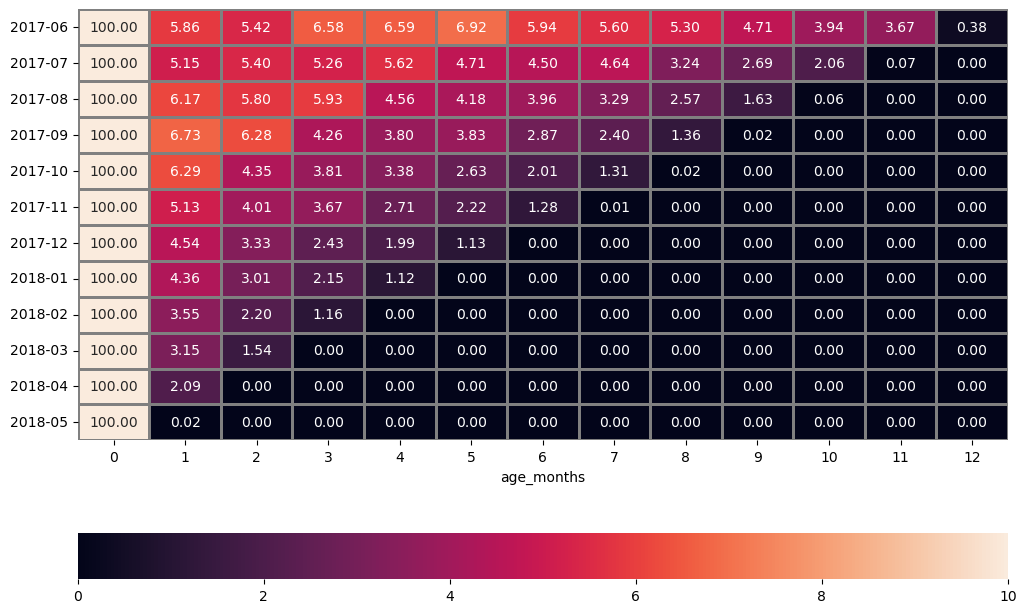

In [48]:
# Creamos un mapa de calor para visualizar la rentecion
plt.figure(figsize=(12,8))
sns.heatmap(retention, annot=True, fmt='.2f', linewidths=1, linecolor='grey', 
            vmax='10', cbar_kws={'orientation': 'horizontal'})
plt.show()

### === Observaciones del analisis de cohortes y la tasa de retencion ===

El mapa de calor muestra mas claramente como la retencion disminuye a lo largo de los meses siguientes a la primera visita. Hay cohortes que mantienen una retencion mas alta, pero en general disminuyen a lo largo del tiempo. Podemos observar tambien que las primeras cohortes parecen tener una mayor rentecion los primeros meses que las cohortes mas nuevas, al menos en el periodo de tiempo que estamos examinando. La cohorte de 2017-06 (junio 2017), es decir, la primera cohorte, es la que presenta una mayor rentencion.

## 2.2 Ventas

¿Cuándo empieza la gente a comprar? (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)

In [49]:
# Imprimir muestra del dataframe orders
orders.head()

,buy_ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [135]:
# Obtenemos la primera orden (compra) por usuario
first_order_date_by_customers = orders.groupby('uid')['buy_ts'].min().reset_index().rename(columns={'buy_ts': 'first_order_date'})

# Unimos el dataset orders con el objeto series de la primera orden por cliente
orders = orders.merge(first_order_date_by_customers, how='inner', on='uid')

In [136]:
orders.head()

,buy_ts,revenue,uid,first_order_date_x,first_order_date_y,first_order_date
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:10:00,2017-06-01 00:10:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:25:00,2017-06-01 00:25:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:27:00,2017-06-01 00:27:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:29:00,2017-06-01 00:29:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:58:00,2017-06-01 07:58:00


### === Observaciones ===

A partir de la fecha de la primera compra podemos calcular el resto para saber cuanto tiempo pasa entre compras y que tan frecuente son las compras por usuarios. Para saber cuando la gente empieza a comprar debemos calcular el tiempo entre la primera visita y la primera compra.

### 2.2.1 ¿Cuándo empieza la gente a comprar?

Para conocer cuando la gente empieza a comprar debemos calcular el lapso de tiempo entre su primera visita y su primera compra, cuando el usuario se convierte en cliente.

In [54]:
# Extraemos del dataframe visitas, las columnas de uid y first_visit_ts y la guardamos en una nueva variable
first_visit_uid = visits_full[['uid','first_visit_ts']]

In [55]:
# Vamos a unir orders_full con first_visit_uid por la columna de uid
orders_full = orders.merge(first_visit_uid, how='inner', on='uid')

# Imprimimos resultado
orders_full

,buy_ts,revenue,uid,first_order_date,first_visit_ts
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:09:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:14:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:25:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:14:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:31:00
...,...,...,...,...,...
761802,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2017-10-23 12:32:00
761803,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2017-10-23 12:32:00
761804,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2017-10-23 12:32:00
761805,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2017-10-23 12:32:00


### === Observaciones ===

Con esto tenemos los datos de la primera visita de cada usuario y la fecha de su primera compra. Ahora podemos calcular el tiempo que tarda cada usuario en convertirse en cliente. Pero primero, observamos que al realizar la union de dataframes se crearon muchas filas que paracen repetidas. Vamos a eliminar los duplicados.

### 2.2.2 Valores duplicados

Al unir los dataframes dio como resultado 761807 filas. Revisamos y por alguna razon que no entiendo se agregaron muchos duplicados. Vamos eliminar esos duplicados.

In [56]:
# Verificar duplicados
print(f"Filas duplicadas en orders_full: {orders_full.duplicated().sum()}")

Filas duplicadas en orders_full: 711392


In [57]:
# Eliminar duplicados
orders_full.drop_duplicates(inplace=True)

In [58]:
# Imprimir resultados
orders_full

,buy_ts,revenue,uid,first_order_date,first_visit_ts
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:09:00
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:14:00
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:25:00
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:14:00
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:31:00
...,...,...,...,...,...
761798,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31 23:50:00,2018-05-31 09:11:00
761800,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31 23:50:00,2018-05-31 23:05:00
761801,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31 23:54:00,2018-05-31 23:52:00
761802,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2017-10-23 12:32:00


In [59]:
# Creamos una columna nueva donde calculamos en tiempo de conversion desde la primera visita hasta la primera compra
orders_full['time_conversion_days'] = (orders_full['first_order_date'] - orders_full['first_visit_ts']).dt.days

In [60]:
# Volvemos a verificar el dataframe
orders_full.head()

,buy_ts,revenue,uid,first_order_date,first_visit_ts,time_conversion_days
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:09:00,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:14:00,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:25:00,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:14:00,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:31:00,0


In [61]:
# Calculamos el tiempo promedio de conversion
print(f"Tiempo promedio de conversion: {orders_full['time_conversion_days'].mean()} dias.")

Tiempo promedio de conversion: 17.419676683526728 dias.


In [62]:
# Agrupamos por tiempo de conversion y contamos cuantos usuarios se convierten por dia
groupby_time_conversion = orders_full.groupby('time_conversion_days')['uid'].count().reset_index()

# Renombramos columnas
groupby_time_conversion.columns = ['time_conversion_days', 'num_users']

# Del total de usuarios que compran, calculamos que porcentaje se transforma en comprador por dia
groupby_time_conversion['percentage_%'] = (groupby_time_conversion['num_users'] / len(orders_full)) * 100

In [63]:
# Imprimimos el resultado
groupby_time_conversion

,time_conversion_days,num_users,percentage_%
0,0,34237,67.910344
1,1,1812,3.594168
2,2,806,1.598731
3,3,642,1.273431
4,4,663,1.315085
...,...,...,...
340,354,1,0.001984
341,355,3,0.005951
342,357,4,0.007934
343,362,1,0.001984


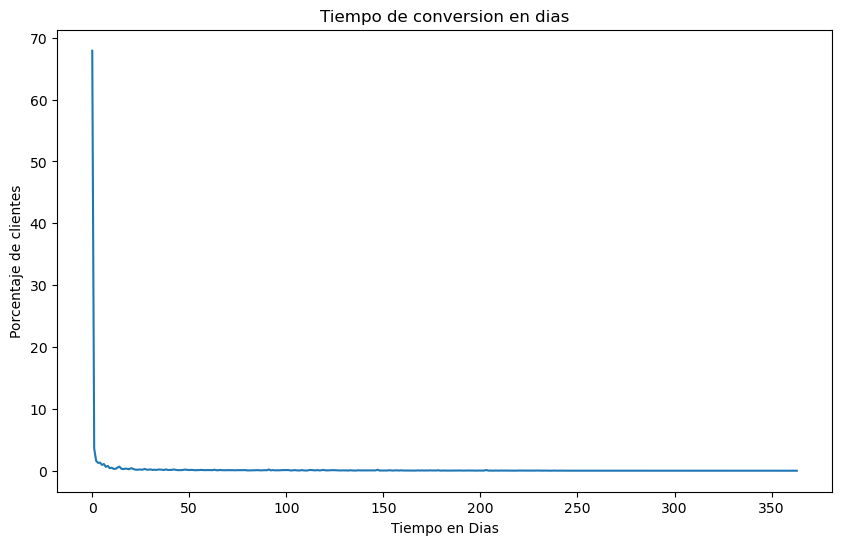

In [64]:
# Creamos una grafica de linea para visualizar la tabla
groupby_time_conversion.plot(title='Tiempo de conversion en dias', kind='line', 
                             x='time_conversion_days', xlabel='Tiempo en Dias', 
                             y='percentage_%', ylabel='Porcentaje de clientes',
                            legend=False, figsize=(10, 6))
plt.show()

### === Observaciones del tiempo de conversion ===

Casi 68% de los clientes se convirtieron el primer dia de su visita. Al siguiente dia solo fue el 3.5% y asi se fue reduciendo muy gradualmente. Seria recomendable saber de donde vinieron esos usuarios que se convirtieron en clientes el primer dia de su visita al sitio.

### 2.2.3 ¿Cuántos pedidos hacen durante un período de tiempo dado?

Para esta seccion vamos a extraer de las fechas, la semana y el mes en que fueron realizadas las compras y agrupar por esos periodos, luego sumamos las ordenes realizadas por cada periodo.

In [66]:
# Creamos una columna para la fecha de cada compra, un columna para la semana y otra para el mes
orders_full['day'] = orders_full['buy_ts'].dt.date
orders_full['week'] = orders_full['buy_ts'].dt.strftime('%Y-%m-%W')
orders_full['month'] = orders_full['buy_ts'].dt.strftime('%Y-%m')

In [67]:
# Revisamos los resultados
orders_full

,buy_ts,revenue,uid,first_order_date,first_visit_ts,time_conversion_days,day,week,month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:09:00,0,2017-06-01,2017-06-22,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:14:00,0,2017-06-01,2017-06-22,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:25:00,0,2017-06-01,2017-06-22,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:14:00,0,2017-06-01,2017-06-22,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:31:00,0,2017-06-01,2017-06-22,2017-06
...,...,...,...,...,...,...,...,...,...
761798,2018-05-31 23:50:00,4.64,12296626599487328624,2018-05-31 23:50:00,2018-05-31 09:11:00,0,2018-05-31,2018-05-22,2018-05
761800,2018-05-31 23:50:00,5.80,11369640365507475976,2018-05-31 23:50:00,2018-05-31 23:05:00,0,2018-05-31,2018-05-22,2018-05
761801,2018-05-31 23:54:00,0.30,1786462140797698849,2018-05-31 23:54:00,2018-05-31 23:52:00,0,2018-05-31,2018-05-22,2018-05
761802,2018-05-31 23:56:00,3.67,3993697860786194247,2018-05-31 23:56:00,2017-10-23 12:32:00,220,2018-05-31,2018-05-22,2018-05


In [68]:
# Agrupamos por dia (fecha) y contamos las ordenes realizadas ese dia para cada dia
orders_grpby_day = orders_full.groupby('day')['buy_ts'].count().reset_index(name='num_orders')
orders_grpby_day

,day,num_orders
0,2017-06-01,96
1,2017-06-02,111
2,2017-06-03,67
3,2017-06-04,66
4,2017-06-05,161
...,...,...
359,2018-05-28,188
360,2018-05-29,189
361,2018-05-30,208
362,2018-05-31,610


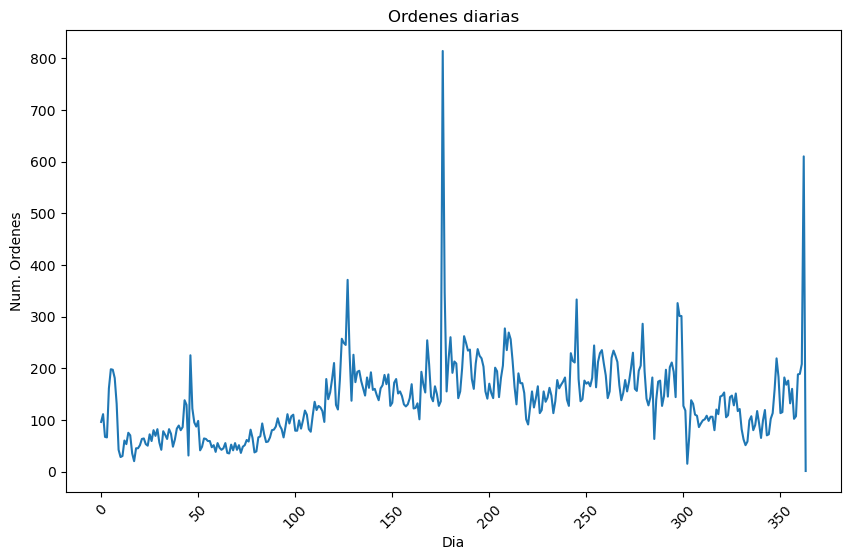

In [121]:
# Graficamos el numero de ordenes diarias
orders_grpby_day.plot(kind='line', title='Ordenes diarias', xlabel='Dia', ylabel='Num. Ordenes', rot=45, figsize=(10, 6), legend=False)
plt.show()

In [70]:
# Agrupamos ordenes por semana y contamos cuantas ordenes se hicieron cada semana
orders_grpby_week = orders_full.groupby('week')['buy_ts'].count().reset_index(name='num_orders')
orders_grpby_week

,week,num_orders
0,2017-06-22,340
1,2017-06-23,938
2,2017-06-24,343
3,2017-06-25,371
4,2017-06-26,362
...,...,...
58,2018-05-19,635
59,2018-05-20,1004
60,2018-05-21,1027
61,2018-05-22,1195


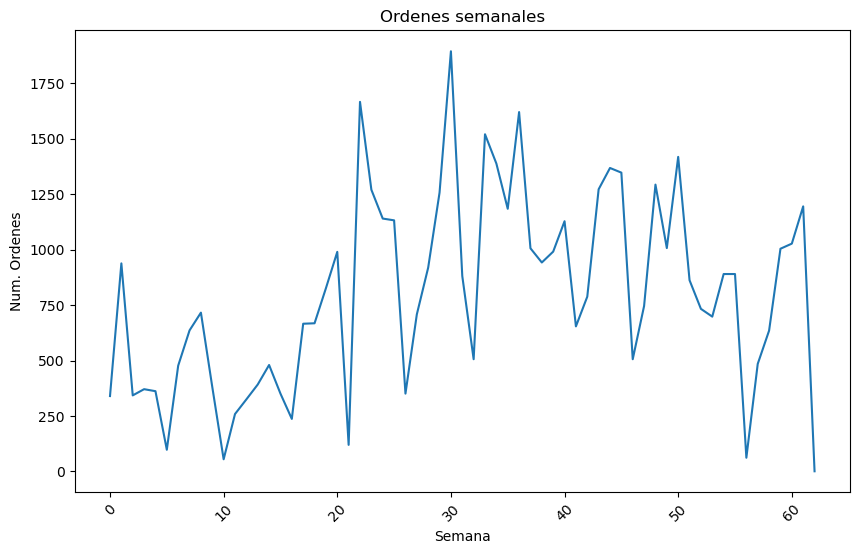

In [71]:
# Graficar el numeros de ordenes semanales
orders_grpby_week.plot(kind='line', title='Ordenes semanales', xlabel='Semana', ylabel='Num. Ordenes', rot=45, figsize=(10, 6), legend=False)
plt.show()

In [72]:
# Graficamos el numero de ordenes mensuales
orders_grpby_month = orders_full.groupby('month')['buy_ts'].count().reset_index(name='num_orders')
orders_grpby_month

,month,num_orders
0,2017-06,2354
1,2017-07,2363
2,2017-08,1807
3,2017-09,3387
4,2017-10,5679
5,2017-11,5659
6,2017-12,6218
7,2018-01,4721
8,2018-02,5281
9,2018-03,5326


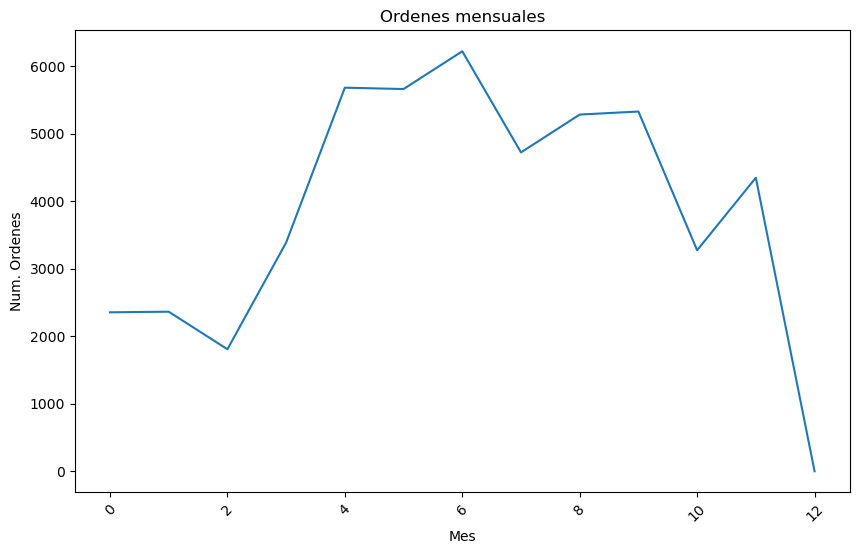

In [122]:
orders_grpby_month.plot(kind='line', title='Ordenes mensuales', xlabel='Mes', ylabel='Num. Ordenes', rot=45, figsize=(10, 6), legend=False)
plt.show()

### === Observaciones de las ordenes diarias, semanales, mensuales ===

Las graficas de ordenes o compras muestran un comportamiento muy similar al de visitas, sin embargo claramente los numeros son menores, no todos los visitantes se convierten en clientes. Pero podemos observar que hay un periodo entre noviembre y diciembre de 2017 que las ventas alcanzan un pico maximo. Es muy probable que sea la fecha de Black Friday.

### 2.2.4 ¿Cuál es el tamaño promedio de compra?

Para esta seccion necesitamos saber cuanto gastan los usuarios en promedio por pedido. Esta metrica la podemos calcular a partir de la columna de 'revenue'.

In [74]:
# Calculamos los ingresos totales
print(f"Ingresos totales: ${orders_full['revenue'].sum()}")

Ingresos totales: $252057.19999999998


In [75]:
# Calculamos el promedio de la columna 'revenue'
print(f"Tamaño promedio de compra: ${orders_full['revenue'].mean()}")

Tamaño promedio de compra: $4.999646930477041


In [76]:
# Usando la funcion describe() tambien podemos calcular el promedio de compra, ademas del maximo y el minimo y la desviacion estandar.
orders_full['revenue'].describe()

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: revenue, dtype: float64

Text(0, 0.5, 'Frecuencia')

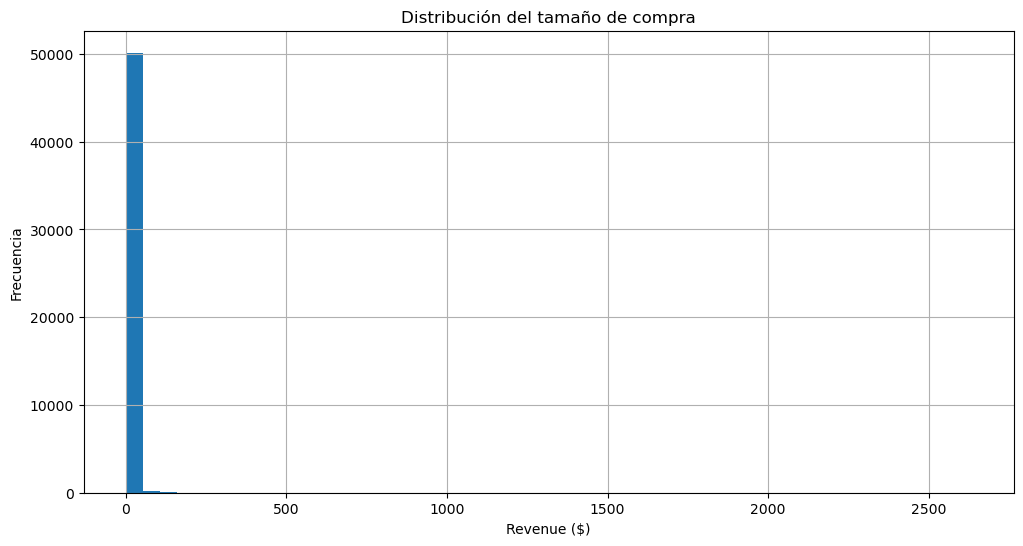

In [77]:
# Ver distribución
orders['revenue'].hist(bins=50, figsize=(12, 6))
plt.title('Distribución del tamaño de compra')
plt.xlabel('Revenue ($)')
plt.ylabel('Frecuencia')

### === Observaciones de tamaño promedio de compra ===

El promedio de compra por pedido es de 4.99, practicamente 5.0. La distribucion esta casi totalmente cargada a la izquierda. Practicamente el total de usuarios gastan menos de 5.0 por pedido. El valor maximo de 2633.28 es anomalo, pero muy agredecidos por este cliente, deberian ofrecerle mas ofertas.

### 2.2.5 ¿Cuánto dinero traen? (LTV)

Queremos saber el LTV (Lifetime Value) por usuario. Es decir, cuanto ingreso aporta cada usuario. Para ello podemos agrupar por 'uid' y calcular la suma total de 'revenue' por usuario.

In [78]:
# Calcular LTV por usuario
ltv_by_user = orders_full.groupby('uid')['revenue'].sum().reset_index()

In [79]:
# Ver algunos ejemplos
print("LTV de los primeros 20 usuarios:")
ltv_by_user.sort_values(by='revenue', ascending=False).head(20)

LTV de los primeros 20 usuarios:


,uid,revenue
11014,5539673724080479777,11810.18
22073,11149926373378902217,10519.46
35670,17999372575896145244,1979.33
13459,6731421022966725351,1450.68
7206,3644482766749211722,1444.29
19248,9737640335185488211,1310.71
16979,8539015707073391293,1240.76
27482,13888745432979765063,1191.02
3276,1668300487562478408,1163.63
12541,6268225112727843212,1158.32


In [80]:
# LTV promedio de todos los clientes
print(f"LTV promedio: ${ltv_by_user['revenue'].mean()}")

LTV promedio: $6.901327930345262


In [81]:
# Estadísticas del LTV
ltv_by_user['revenue'].describe()

count    36523.000000
mean         6.901328
std         88.128535
min          0.000000
25%          1.470000
50%          3.050000
75%          5.800000
max      11810.180000
Name: revenue, dtype: float64

Text(0, 0.5, 'Número de usuarios')

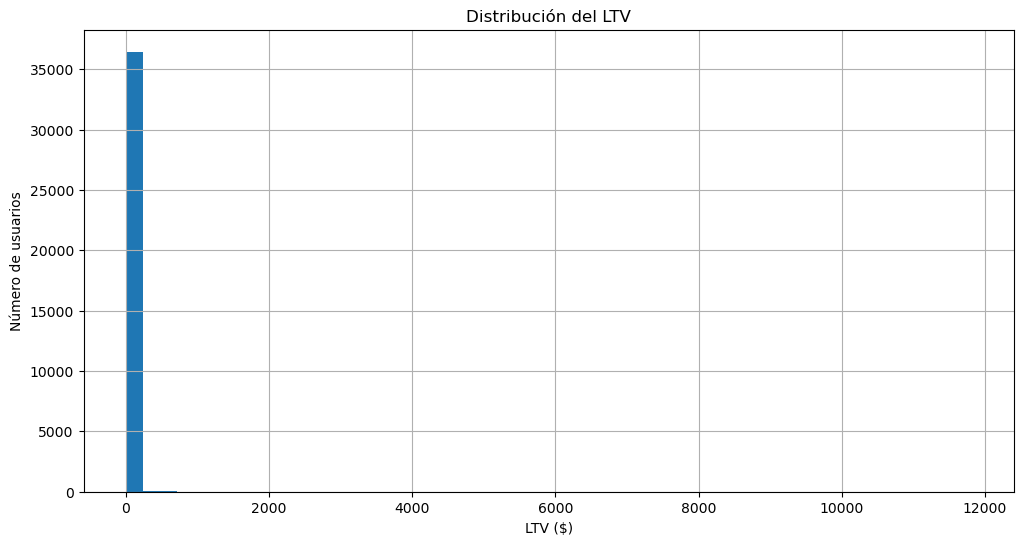

In [82]:
# Distribución del LTV
plt.figure(figsize=(12, 6))
ltv_by_user['revenue'].hist(bins=50)
plt.title('Distribución del LTV')
plt.xlabel('LTV ($)')
plt.ylabel('Número de usuarios')

### === Observaciones de LTV ===

Tenemos un total de 36,523 clientes, con un LTV promedio de 6.9. La grafica de distribucion muestra como la inmensa mayoria en realidad han aportado alrededor de esa cantidad total. Sin embargo, la lista de los primeros 20 clientes por LTV muestra que hay un pequeño porcentaje de clientes que han aportado mas de 600, e incluso dos cliente en particular que han llegado a comprar mas $10,000, siendo estos los clientes mas valiosos por mucho.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Excelente cálculo de LTV (Lifetime Value). La metodología es correcta: agrupar por usuario y sumar el revenue total. Este es un componente clave para el análisis de rentabilidad y la evaluación de fuentes de marketing.

Ya solamente puedes complementar con un gráfico para mostrar los resultados por fecha

### 2.2.6 Cohorte de Clientes

In [83]:
# Creamos las columnas para la fecha de la primera compra por dia , semana y mes.
orders_full['first_order_day'] = orders_full['first_order_date'].dt.date
orders_full['first_order_week'] = orders_full['first_order_date'].dt.strftime('%Y-%m-%W')
orders_full['first_order_month'] = orders_full['first_order_date'].dt.strftime('%Y-%m')

In [84]:
# Imprimimos vista preliminar
orders_full.head()

,buy_ts,revenue,uid,first_order_date,first_visit_ts,time_conversion_days,day,week,month,first_order_day,first_order_week,first_order_month
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:09:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:14:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:25:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:14:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:31:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06


In [138]:
# Calculamos la edad de cada compra en dias desde la primera compra y lo agregamos como un columna nueva
orders_full['age_days'] = (orders_full['day'] - orders_full['first_order_day'])

# Ahora calculamos la edad de cada compra en meses (desde la primera compra) y agregamos la columna
orders_full['age_months'] = orders_full['age_days'] / (np.timedelta64(30, 'D'))

# Cambiamos el tipo de dato de la columna a entero
orders_full['age_months'] = orders_full['age_months'].astype('int')

In [86]:
# Imprimimos resultado
orders_full.head()

,buy_ts,revenue,uid,first_order_date,first_visit_ts,time_conversion_days,day,week,month,first_order_day,first_order_week,first_order_month,age_days,age_months
0,2017-06-01 00:10:00,17.00,10329302124590727494,2017-06-01 00:10:00,2017-06-01 00:09:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06,0:00:00,0
1,2017-06-01 00:25:00,0.55,11627257723692907447,2017-06-01 00:25:00,2017-06-01 00:14:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06,0:00:00,0
2,2017-06-01 00:27:00,0.37,17903680561304213844,2017-06-01 00:27:00,2017-06-01 00:25:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06,0:00:00,0
3,2017-06-01 00:29:00,0.55,16109239769442553005,2017-06-01 00:29:00,2017-06-01 00:14:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06,0:00:00,0
4,2017-06-01 07:58:00,0.37,14200605875248379450,2017-06-01 07:58:00,2017-06-01 07:31:00,0,2017-06-01,2017-06-22,2017-06,2017-06-01,2017-06-22,2017-06,0:00:00,0


In [ ]:
# Crear la cohorte de compras usando pivot_table()
cohort_orders = orders_full.pivot_table(index='first_order_month', 
                                       columns='age_months',
                                       values='revenue',
                                       aggfunc='sum'
                                       )

In [ ]:
# Imprimir la cohorte orders
cohort_orders

age_months,0,1,2,3,4,5,6,7,8,9,10,11,12
first_order_month,,,,,,,,,,,,,
2017-06,9916.73,774.31,996.07,2354.12,1614.66,1930.47,1344.91,1214.25,1168.08,1256.60,991.20,430.33,39.96
2017-07,11906.30,594.53,1304.21,346.19,332.99,277.45,238.87,332.87,227.15,302.64,255.56,9.16,NaN
2017-08,7624.96,635.24,677.44,490.05,554.31,336.32,343.22,567.81,254.18,122.73,NaN,NaN,NaN
2017-09,16255.88,1780.73,9244.07,2414.52,1603.40,1488.99,1092.39,352.24,433.71,10.39,NaN,NaN,NaN
2017-10,23087.34,1334.69,760.93,769.60,510.02,362.71,368.99,407.64,1.53,NaN,NaN,NaN,NaN
2017-11,21943.79,1075.79,1096.57,1137.88,283.31,271.82,289.83,NaN,NaN,NaN,NaN,NaN,NaN
2017-12,21284.61,1712.31,4185.53,3563.62,1418.18,1318.44,3.05,NaN,NaN,NaN,NaN,NaN,NaN
2018-01,14730.47,858.81,758.52,220.17,95.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-02,15861.31,452.54,272.17,164.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


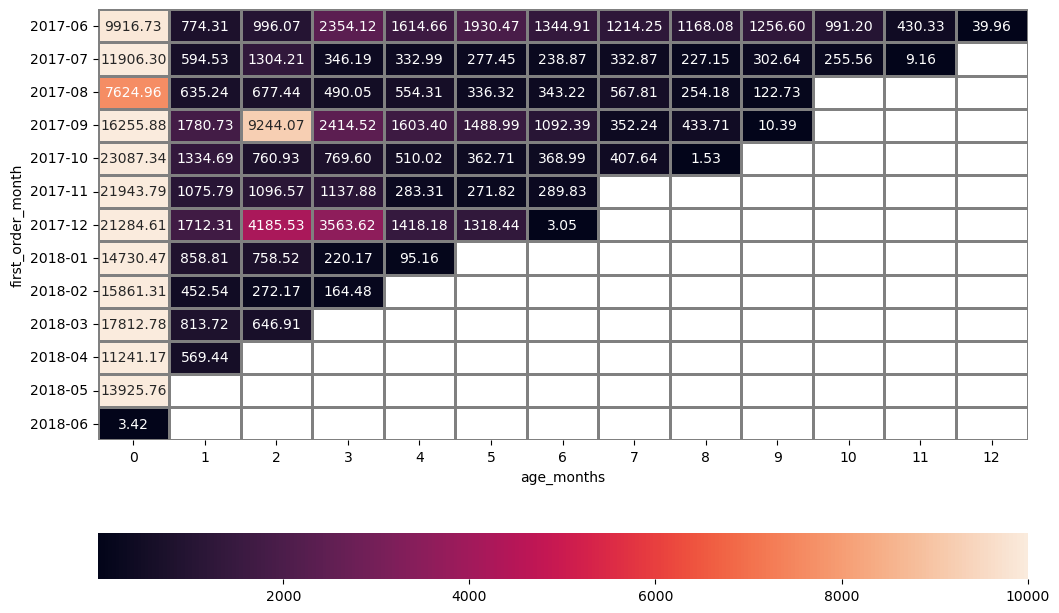

In [ ]:
# Crear un mapa de calor para visualizar mejor los resultados
plt.figure(figsize=(12,8))
sns.heatmap(cohort_orders, annot=True, fmt='.2f', linewidths=1, linecolor='grey', 
            vmax='10000', cbar_kws={'orientation': 'horizontal'})
plt.show()

## 2.3 Marketing

 1. ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 
 2. ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?
 3. ¿Cuán rentables eran las inversiones? (ROMI)

Traza gráficos para mostrar cómo difieren estas métricas para varios dispositivos y fuentes de anuncios y cómo cambian con el tiempo. 

### 2.3.1 ¿Cuánto dinero se gastó? (Total)

Queremos saber cuanto fue el gasto total en marketing. Esta metrica podemos obtenerla sumando toda la columna de costos.

In [90]:
# Vista preliminar de la tabla costos
costs

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08
...,...,...,...
2537,10,2018-05-27,9.92
2538,10,2018-05-28,21.26
2539,10,2018-05-29,11.32
2540,10,2018-05-30,33.15


In [91]:
# Usamos el metodo describe() para sacar algunas estadisticas utiles de la columna costos
costs['costs'].describe()

count    2542.000000
mean      129.477427
std       156.296628
min         0.540000
25%        21.945000
50%        77.295000
75%       170.065000
max      1788.280000
Name: costs, dtype: float64

In [92]:
# Costo total de marketing
print(f"Costos totales de marketing: ${costs['costs'].sum()}")

Costos totales de marketing: $329131.62


EL costo total en marketing asciende a $329,131.62.

### 2.3.2 ¿Cuánto dinero se gastó? (Por fuente de adquisicion)

Ahora nos interesa saber cuanto se gasto por fuente. Para ello, tenemos que agrupar por source_id y sumar los gastos de cada fuente.

In [93]:
# Agrupamos por source_id para crear una tabla de los costos por fuente de marketing
costs_by_source = costs.groupby('source_id')['costs'].sum().reset_index()

# Mostramos la tabla
costs_by_source

,source_id,costs
0,1,20833.27
1,2,42806.04
2,3,141321.63
3,4,61073.60
4,5,51757.10
5,9,5517.49
6,10,5822.49


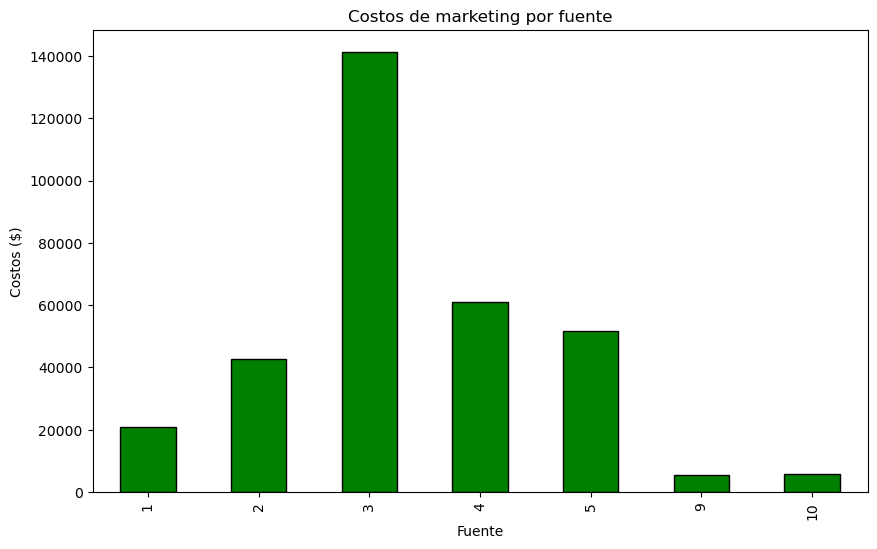

In [94]:
# Graficar los costos por fuente
costs_by_source.plot(kind='bar', title='Costos de marketing por fuente', x='source_id', y='costs',
                    xlabel='Fuente', ylabel='Costos ($)', color='green', edgecolor='black', legend=False, figsize=(10, 6))
plt.show()

### === Observaciones (Por fuente de adquisicion) ===

No conocemos los nombres exactos de las fuentes, pero la fuente 3 se llevo un presupuesto de $141321 y por mucho es la fuente de marketing que mas gasto. Seguido de las fuentes 4 y 5 cada una 61073 y 51757 en gastos respectivamente. Las fuentes donde menos se invirtio fueron la 9 y 10 con 5517 y 5822 respectivamente.

### 2.3.3 ¿Cuánto dinero se gastó?  (a lo largo del tiempo) 

Tambien nos interesa saber como se fue gastando en marketing a lo largo del periodo de tiempo de nuestros datos, es decir, desde Junio 2017 hasta Mayo 2018. Inicialmente los datos estan en dias completos, por lo que podemos agrupar por semanas o mas convenientemente por meses y obtener la cantidad invertida cada mes a lo largo del periodo de tiempo de nuestros datos.

In [95]:
# Agregamos las columnas de semana y mes para poder agrupar por estos mas adelante
costs['week'] = costs['dt'].dt.strftime('%Y-%m-%W')
costs['month'] = costs['dt'].dt.strftime('%Y-%m')

In [96]:
# Mostramos la tabla
costs

,source_id,dt,costs,week,month
0,1,2017-06-01,75.20,2017-06-22,2017-06
1,1,2017-06-02,62.25,2017-06-22,2017-06
2,1,2017-06-03,36.53,2017-06-22,2017-06
3,1,2017-06-04,55.00,2017-06-22,2017-06
4,1,2017-06-05,57.08,2017-06-23,2017-06
...,...,...,...,...,...
2537,10,2018-05-27,9.92,2018-05-21,2018-05
2538,10,2018-05-28,21.26,2018-05-22,2018-05
2539,10,2018-05-29,11.32,2018-05-22,2018-05
2540,10,2018-05-30,33.15,2018-05-22,2018-05


#### Gastos de marketing diarios

In [97]:
# Solo para tener la imagen y hacer una comparativa, vamos a calcular los gastos en marketing diarios
costs_by_day = costs.groupby('dt')['costs'].sum().reset_index()

# Imprimimos la tabla de gastos diarios de marketing
costs_by_day

,dt,costs
0,2017-06-01,735.26
1,2017-06-02,721.19
2,2017-06-03,450.85
3,2017-06-04,761.16
4,2017-06-05,821.44
...,...,...
359,2018-05-27,532.87
360,2018-05-28,619.44
361,2018-05-29,784.79
362,2018-05-30,1183.00


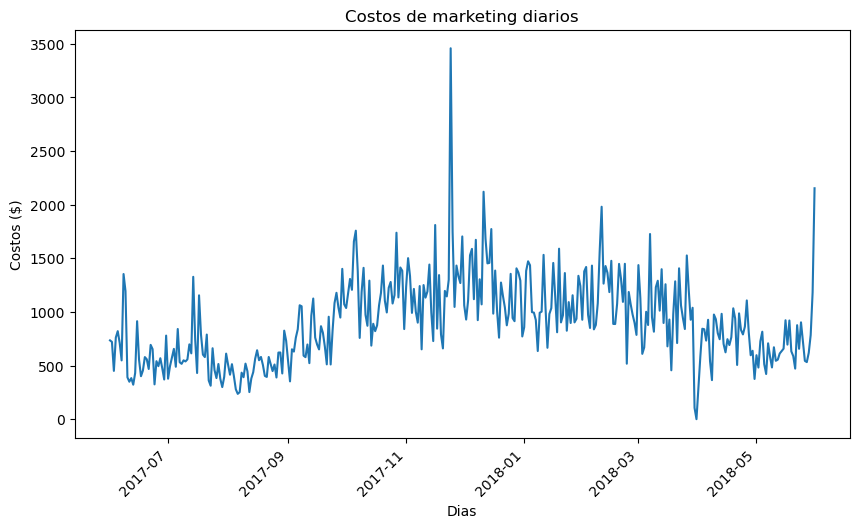

In [98]:
# Creamos una grafica de los gastos diarios en marketing
costs_by_day.plot(kind='line', title='Costos de marketing diarios', x='dt', y='costs',
                  xlabel='Dias', ylabel='Costos ($)', rot=45, figsize=(10, 6), legend=False)
plt.show()

#### Gastos en marketing semanales

In [99]:
# Agrupamos por semanas y sumamos los costos totales por semana
costs_by_week = costs.groupby('week')['costs'].sum().reset_index()

# Mostramos la tabla
costs_by_week

,week,costs
0,2017-06-22,2668.46
1,2017-06-23,5372.71
2,2017-06-24,3462.49
3,2017-06-25,3821.75
4,2017-06-26,2689.59
...,...,...
57,2018-05-18,3558.33
58,2018-05-19,4159.23
59,2018-05-20,5055.92
60,2018-05-21,4709.86


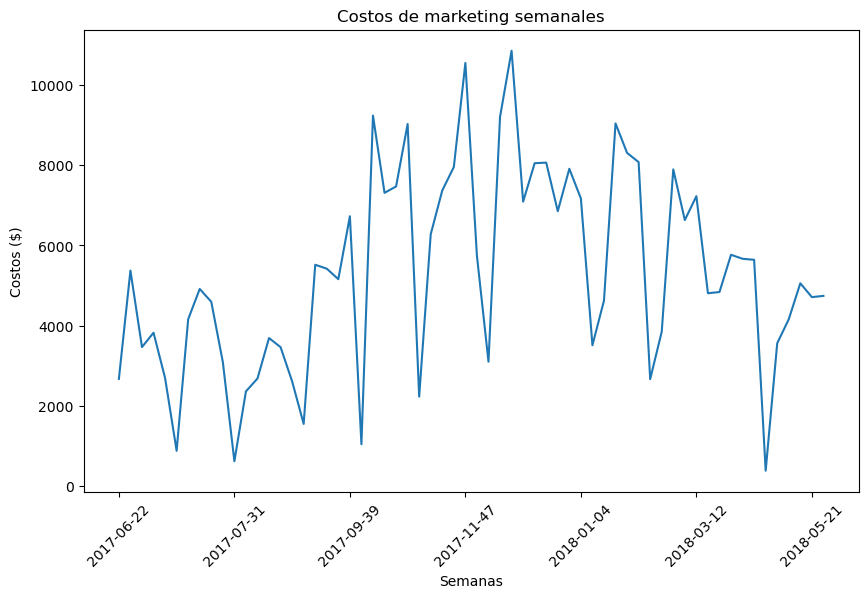

In [100]:
# Graficamos la tabla de gastos por semana
costs_by_week.plot(kind='line', title='Costos de marketing semanales', x='week', y='costs',
                  xlabel='Semanas', ylabel='Costos ($)', rot=45, figsize=(10, 6), legend=False)
plt.show()

#### Gastos de marketing mensuales

In [101]:
# Agrupamos por mes y sumamos los costos de cada mes
costs_by_month = costs.groupby('month')['costs'].sum().reset_index()

# Mostramos la tabla de gastos mensuales
costs_by_month

,month,costs
0,2017-06,18015.00
1,2017-07,18240.59
2,2017-08,14790.54
3,2017-09,24368.91
4,2017-10,36322.88
5,2017-11,37907.88
6,2017-12,38315.35
7,2018-01,33518.52
8,2018-02,32723.03
9,2018-03,30415.27


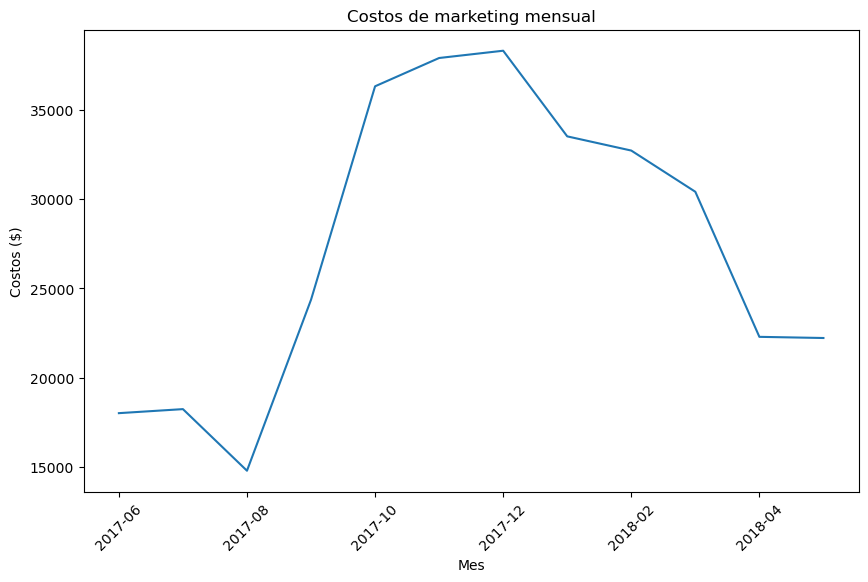

In [102]:
# Graficamos los gastos mensuales de marketing
costs_by_month.plot(kind='line', title='Costos de marketing mensual', x='month', y='costs',
                  xlabel='Mes', ylabel='Costos ($)', rot=45, figsize=(10, 6), legend=False)
plt.show()

### === Observaciones en gastos de marketing a lo largo del tiempo ===

Es interesante observar como estas graficas de gastos de marketing por periodos (diario, semanal y mensual) presentan un comportamiento practicamente identico a las graficas de visitas y ordenes para los mismos periodos. Podemos aventurarnos a decir que al menos los gastos en marketing han tenido un efecto 1:1 para las visitas y los ingresos, pero claro, necesitamos obtener los numeros para saber si la inversion en marketing ha valido la pena.

### 2.3.4 ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [103]:
# Sumar gastos por fuente
gastos_por_fuente = costs.groupby('source_id')['costs'].sum()
gastos_por_fuente

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

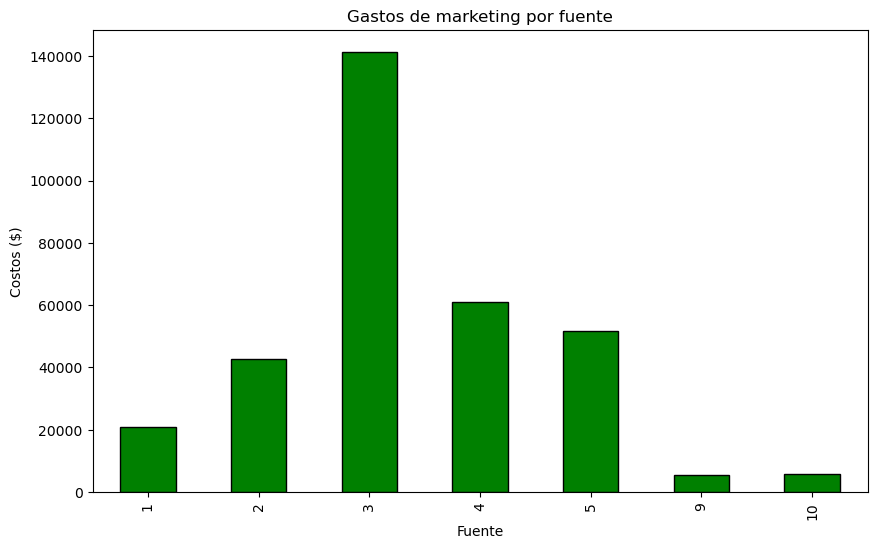

In [104]:
# Graficar los gastos por fuente
gastos_por_fuente.plot(kind='bar', title='Gastos de marketing por fuente',
                  xlabel='Fuente', ylabel='Costos ($)', figsize=(10, 6), color='green', edgecolor='black', legend=False)
plt.show()

In [105]:
# Usuarios que hicieron al menos una compra, por fuente
clientes_por_fuente = visits.merge(orders, on='uid') \
                           .groupby('source_id')['uid'].nunique()
clientes_por_fuente

source_id
1      7138
2      7305
3     13846
4     14253
5     10156
7         1
9      2793
10     1773
Name: uid, dtype: int64

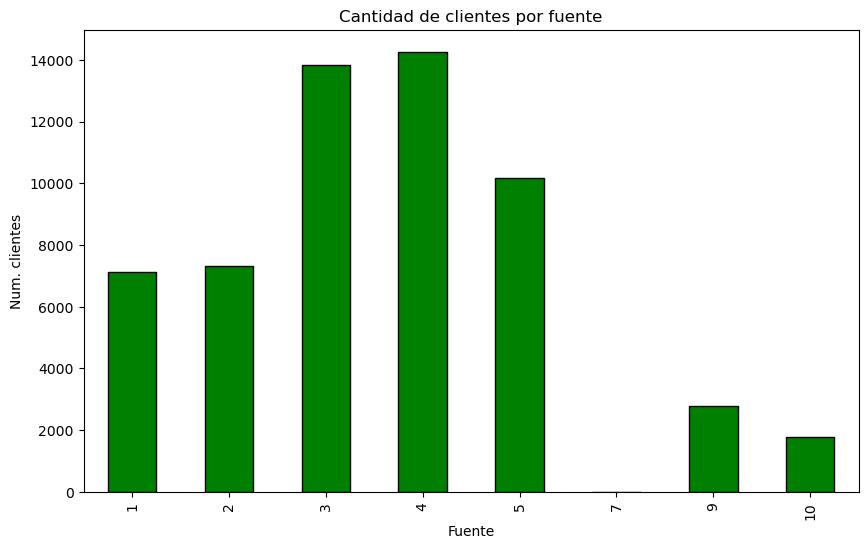

In [106]:
# Graficar clientes por fuente
clientes_por_fuente.plot(kind='bar', title='Cantidad de clientes por fuente',
                  xlabel='Fuente', ylabel='Num. clientes', figsize=(10, 6), color='green', edgecolor='black', legend=False)
plt.show()

In [107]:
# CAC por fuente
cac_por_fuente = gastos_por_fuente / clientes_por_fuente
cac_por_fuente

source_id
1      2.918642
2      5.859828
3     10.206676
4      4.284965
5      5.096209
7           NaN
9      1.975471
10     3.283976
dtype: float64

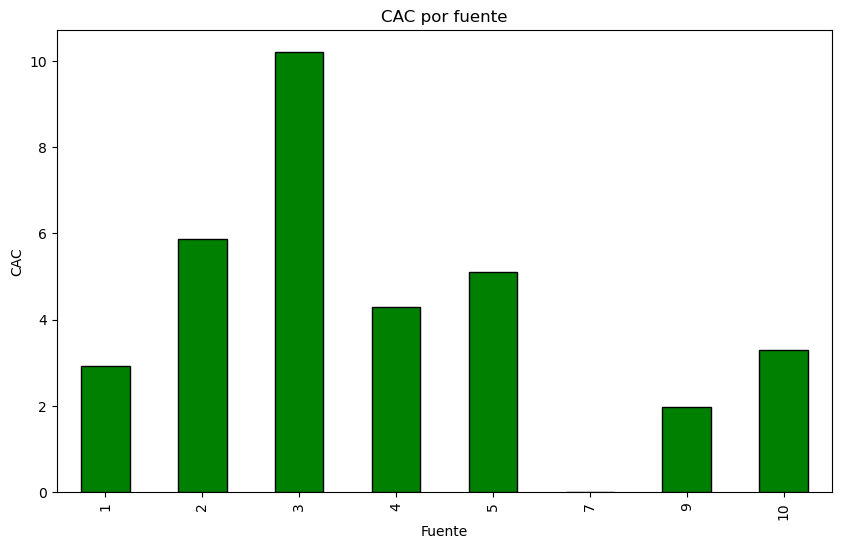

In [108]:
# Graficar CAC por fuente
cac_por_fuente.plot(kind='bar', title='CAC por fuente',
                  xlabel='Fuente', ylabel='CAC', figsize=(10, 6), color='green', edgecolor='black', legend=False)
plt.show()

### === Observaciones del Costo de adquisicion de clientes (CAC) ===

Cada cliente de la fuente 3 cuesta 10.2, es la fuente de marketing que mas cuesta. Mientras que la fuente 9 y 1 son las mas economicas y aportan una cantidad respetable de clientes.

### 2.3.5 ¿Cuán rentables eran las inversiones? (ROMI)

Finalmente tenemos que evaluar el retorno de inversion en marketing (ROMI), para determinar que tan beneficiosas han sido las inversiones de cada fuente.

In [109]:
# Calcular ingresos por dispositivo
ingresos_por_dispositivo = visits.merge(orders, on='uid')
ingresos_por_dispositivo = ingresos_por_dispositivo.groupby('device')['revenue'].sum().reset_index()
ingresos_por_dispositivo


,device,revenue
0,desktop,6447893.99
1,touch,514313.36


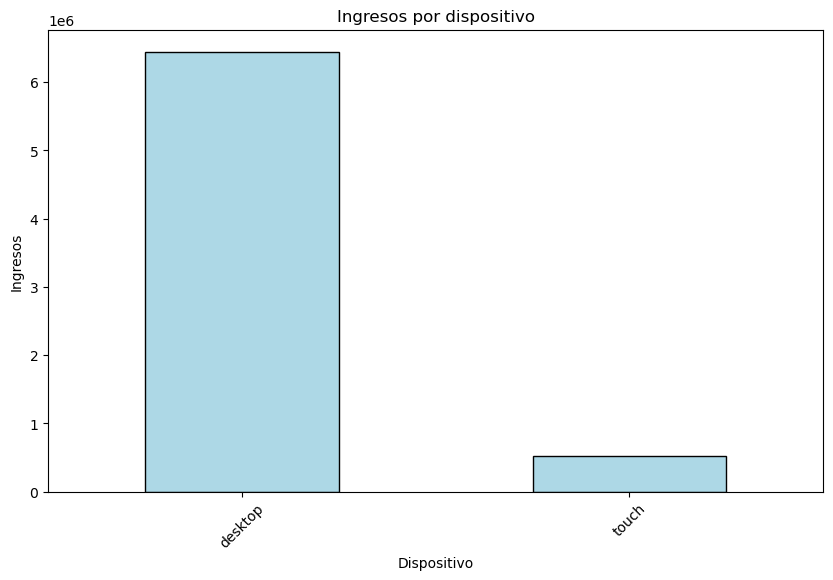

In [110]:
# Graficar
ingresos_por_dispositivo.plot(kind='bar', title='Ingresos por dispositivo', x='device', y='revenue',
                  xlabel='Dispositivo', ylabel='Ingresos', figsize=(10, 6), color='lightblue', edgecolor='black', rot=45, legend=False)
plt.show()

In [111]:
# Mostramos los gastos por fuente
gastos_por_fuente

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64

In [112]:
# Unir visits con orders para saber qué fuente generó cada venta
ingresos_por_fuente = visits.merge(orders, on='uid')
ingresos_por_fuente.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,session_duration_sec,buy_ts,revenue,first_order_date
0,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,2018-05-20,2018-05-20,2018-05,1440,2018-03-09 20:25:00,2.33,2018-03-09 20:25:00
1,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,2017-09-35,2017-09,60,2017-09-04 12:46:00,2.44,2017-09-04 12:46:00
2,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,2017-09-35,2017-09,60,2017-10-28 00:01:00,1.53,2017-09-04 12:46:00
3,desktop,2017-09-03 21:36:00,5,2017-09-03 21:35:00,16007536194108375387,2017-09-03,2017-09-35,2017-09,60,2017-10-28 19:16:00,1.53,2017-09-04 12:46:00
4,desktop,2018-02-06 15:50:00,4,2018-02-06 15:45:00,8056418121947262981,2018-02-06,2018-02-06,2018-02,300,2017-06-25 08:54:00,3.67,2017-06-25 08:54:00


In [113]:
# Agrupar por source_id y calcular la suma de revenue por fuente
ingresos_por_fuente_grpby = ingresos_por_fuente.groupby('source_id')['revenue'].sum()

In [114]:
# Imprimir resultados
ingresos_por_fuente_grpby

source_id
1     2298200.17
2     2638189.21
3      296687.96
4      496690.17
5     1181477.14
7           1.22
9       36342.25
10      14619.23
Name: revenue, dtype: float64

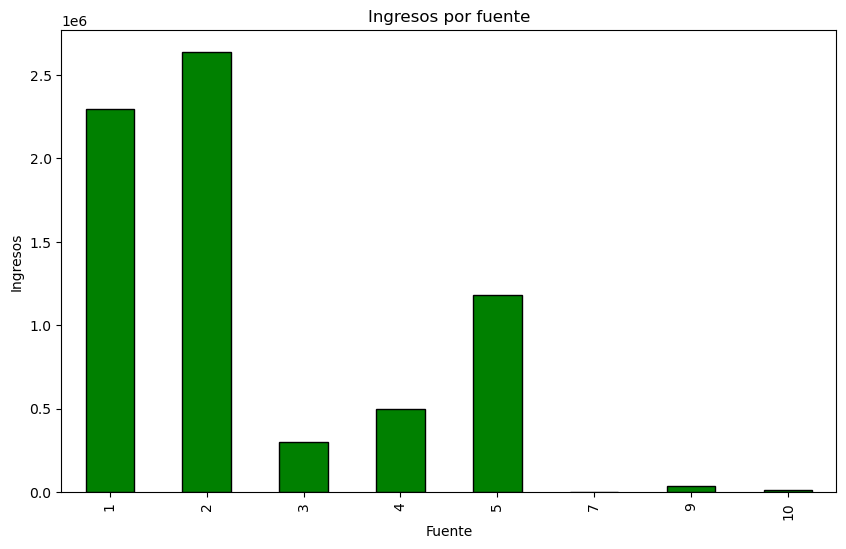

In [115]:
ingresos_por_fuente_grpby.plot(kind='bar', title='Ingresos por fuente',
                  xlabel='Fuente', ylabel='Ingresos', figsize=(10, 6), color='green', edgecolor='black', legend=False)
plt.show()

In [116]:
# ROMI por fuente
romi_por_fuente = ingresos_por_fuente_grpby / gastos_por_fuente

# O con ganancia neta
romi_neto = (ingresos_por_fuente_grpby - gastos_por_fuente) / gastos_por_fuente

In [117]:
# Imprimimos resultados
romi_por_fuente

source_id
1     110.313944
2      61.631237
3       2.099381
4       8.132649
5      22.827344
7            NaN
9       6.586736
10      2.510821
dtype: float64

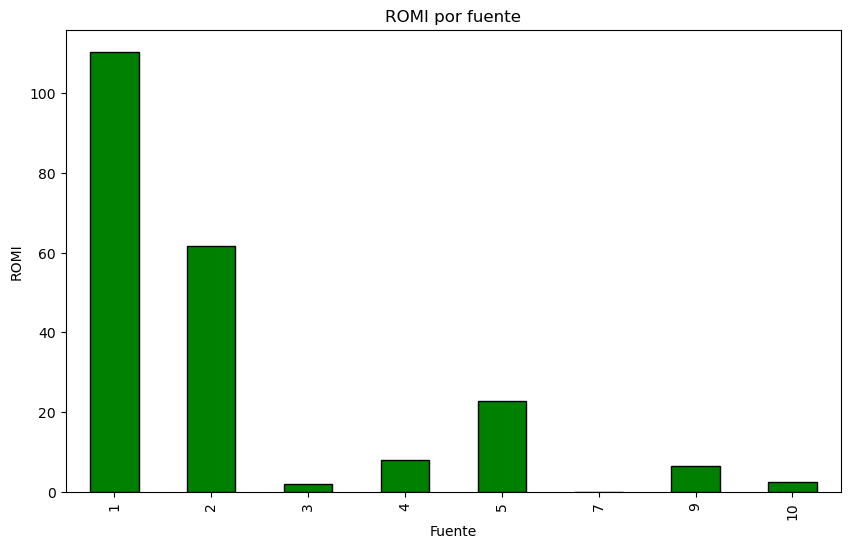

In [118]:
# Grafica
romi_por_fuente.plot(kind='bar', title='ROMI por fuente',
                  xlabel='Fuente', ylabel='ROMI', figsize=(10, 6), color='green', edgecolor='black', legend=False)
plt.show()

In [119]:
# Imprimimos resultados
romi_neto

source_id
1     109.313944
2      60.631237
3       1.099381
4       7.132649
5      21.827344
7            NaN
9       5.586736
10      1.510821
dtype: float64

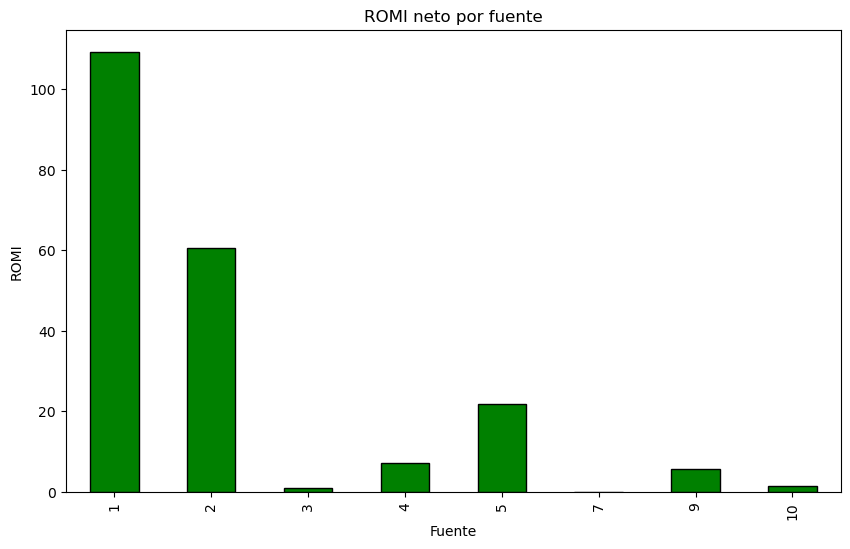

In [120]:
# Grafica
romi_neto.plot(kind='bar', title='ROMI neto por fuente',
                  xlabel='Fuente', ylabel='ROMI', figsize=(10, 6), color='green', edgecolor='black', legend=False)
plt.show()

### === Observaciones de los retornos de inversion ===

El ROMI ha valido la pena en varias fuentes. La que mas ha generado ha sido la fuente 1 seguido de la 2. Sin embargo no podemos decir lo mismo de la fuente 3 que ha sido la fuente donde mas se ha invertido y apenas ha generado un beneficio. Las fuentes 4, 5, 9 y 10 presentan beneficios que podriamos llamar saludables. Por otro lado la plataforma o dispositivo desde donde se calculan mayores ingresos es Desktop, es decir, computadoras o laptops.

## Paso 3. Conclusiones

¿Qué fuentes/plataformas recomendarías?  Fundamenta tu selección: ¿en qué métricas te enfocaste?  ¿Por qué? ¿Qué conclusiones sacaste después de encontrar los valores métricos?

### Conclusiones y recomendaciones

* Las fuentes de marketing que registraron un ROMI mas alto fueron la 1 y 2 por mucho, 109.3 y 60.6 respectivamente. Un tanto mas abajo la fuente 5 con 21.8. De ahi las fuentes 4 y 9 generaron un ROMI de 7.1 y 5.6 respectivamente. La fuente de 3 solo ha generado un ROMI de 1.09 y la fuente 7 es casi nula y no sabemos de donde salio.

* En cuanto a las plataformas o dispositivos tenemos que los dispositivos de escritorio (desktop, laptops, etc) aportan mayores ingresos, aproximadamente mas 10 veces mas comparado con los dispositivos touch (dispositivos moviles y portatiles). Definitivamente se pueden atraer mas clientes de dispositivos moviles, pero sin duda los usuarios y cliente provenientes de desktop deben tener mayor prioridad por el porcentaje tan alto de ingresos que aportan.

* He visto que las fuentes 1 y 2 presentan los mejores margenes de ROMI, por lo que se puede mantener la estrategia en estas fuentes. Por otro lado observamos como la fuente 3 ha sido la que mayores gastos ha tenido, pero su retorno de inversion no ha sido muy favorable. Claramente se deben revisar las estrategias de marketing para la fuente 3 y quiza reducir gastos para esa fuente. Las fuentes 4, 5, 9 y 10 presentan un ROMI mas favorable, pero nada excepcional, por lo que tambien se podrian revisar las estrategias para esos canales de marketing.

* La inversion realizada para la fuente 3 podria distribuirse a las demas fuentes y comprobar si las demas fuentes son mas rentables. La razon por la que las fuentes 1 y 2 tienen un ROMI mas alto es en parte porque la inversion en dichas fuentes no fue tan elevada en comparacion con la fuente 3 por ejemplo, y sin embargo lograron retornos de inversion mas altos. Se debe considerar revisar la estrategia de inversion por fuente de marketing para optimizar y mejorar el ROMI de cada fuente.

* Otro punto ha tener en cuenta es la tasa de retencion de visitas. Todas las cohortes presentan numeros mas altos en su primer mes de visita y sabemos que esos numeros decaen con el tiempo, pero se podria considerar alguna estrategia que logre mantener cierta estabilidad en las visitas, ofertas, promociones o articulos nuevos. Alguna forma que incentive los clicks y las visitas constantes al menos para saber que hay de nuevo en Showz.
